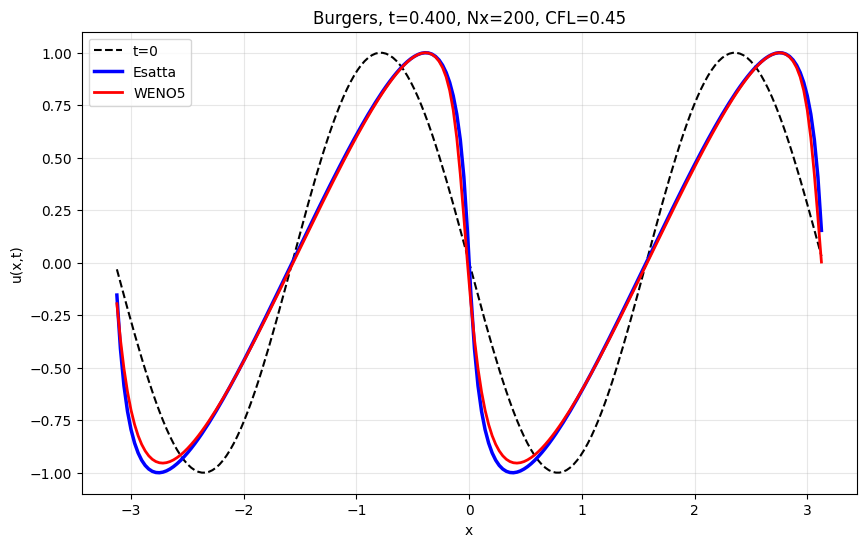

In [2]:
# Burgers – WENO5 con flux splitting Lax–Friedrichs e SSP‑RK3
import numpy as np
import matplotlib.pyplot as plt

# Parametri globali
AMP   = 1.0        # Ampiezza massima dell'onda sinusoidale iniziale u0
XMIN  = -np.pi     # Estremo sinistro del dominio spaziale di calcolo
XMAX  =  np.pi     # Estremo destro del dominio spaziale di calcolo
NX    = 200        # Numero di punti (celle) usati per la discretizzazione spaziale numerica
CFL   = 0.45       # Coefficiente di Courant-Friedrichs-Lewy per la stabilità del passo temporale dt
T_FINAL = 0.4      # Tempo finale della simulazione numerica in cui calcolare la soluzione

NX_EXACT   = 2000  # Numero di punti di campionamento usati per calcolare la soluzione esatta
EXT_FACTOR = 3.0   # Moltiplicatore per estendere il dominio di ricerca delle caratteristiche all'indietro

def u0(x):
    # Condizione iniziale al tempo t=0: definisce il profilo iniziale dell'onda in base a x
    return AMP * np.sin(np.pi + 2*x)

def bisezione_burgers(u0_func, x, t, lo, hi, glo):
    """ Risolve localmente la funzione g(x0) = 0 usando esattamente 64 iterazioni fisse, sfruttando la massima precisione della macchina senza l'uso di una tolleranza. """
    for _ in range(64):     # Esegue 64 cicli di bisezione per stringere l'intervallo sulla radice esatta
        mid = 0.5 * (lo + hi) # Calcola il punto medio dell'intervallo corrente
        gm = mid + u0_func(mid) * t - x # Ricalcola la funzione g nel punto medio
        if glo * gm <= 0:
            hi = mid        # La radice sta nella metà sinistra, quindi sposta il limite destro
        else:
            lo, glo = mid, gm # La radice sta nella metà destra, quindi sposta il limite sinistro
    return 0.5 * (lo + hi)  # Restituisce la coordinata x0 finale (punto medio dell'intervallo ridotto)

def exact_burgers(u0_func, x_vec, t, Ns=2000, ext_factor=3.0):
    n = len(x_vec)          # Numero di punti della griglia numerica su cui calcolare l'esatta
    u_out = np.zeros(n)     # Array vuoto che conterrà i valori finali della soluzione esatta
    if t < 1e-14:           # Al tempo t=0 mettiamo i valori di u_0
        return np.array([u0_func(xi) for xi in x_vec])
    xmin, xmax = x_vec[0], x_vec[-1] # Estremi reali del vettore spaziale passato in input
    L = xmax - xmin         # Lunghezza del dominio spaziale
    maxU0 = 0.1             # Valore minimo di soglia per stimare la velocità massima iniziale
    Nc = 500                # Numero di sotto-intervalli per la ricerca del massimo globale di u0
    for j in range(Nc+1):   # Cerca il massimo di U_0
        xc = xmin - L + j * (3*L/Nc) # campionando 500 (Nc) punti nell'intervallo (x_min-L,x_max+L),
        v = u0_func(xc) # il 3 compare perchè l'intervallo ha lunghezza (x_max+L) - (x_min-L) = 3L
        if np.isfinite(v) and abs(v) > maxU0:
            maxU0 = abs(v)  # Salva il valore massimo assoluto trovato in u0
    # Se u0 è grande, estende in base a quanto viaggiano veloci le caratteristiche per non perderle; se è basso,
    # usa comunque 3*L come margine minimo di sicurezza
    ext = max(ext_factor * L, 2.0 * maxU0 * t) + 2.0
    x0min, x0max = xmin - ext, xmax + ext # Nuovi confini estesi del dominio per la griglia ausiliaria
    xs = np.linspace(x0min, x0max, Ns)    # Crea una griglia ausiliaria di Ns punti nel dominio esteso
                                          # (servirà per la ricerca delle caratteristiche)
    u0s = np.nan_to_num(np.array([u0_func(xi) for xi in xs]), nan=0.0) # Calcola u0 sulla griglia fitta
    # azzerando eventuali valori NaN che possono comparire se alcuni punti cadono fuori dal dominio reale di u0
    # Risolve l'equazione delle caratteristiche x = x0 + u0(x0)*t per ogni punto x del vettore numerico
    for idx, x in enumerate(x_vec): # Per ogni x della griglia numerica originale
        gs = xs + u0s * t - x  # Vettore che è lungo Ns, definisce g(x0) = x0 + u0(x0)*t - x di cui cercare gli zeri
        # gs[i] ti dice quanto è distante dall'obiettivo x la caratteristica partita da xs[i].

        cands = []  # Lista per raccogliere le radici trovate
        for j in range(Ns-1):
            if gs[j] * gs[j+1] <= 0: # Se c'è un cambio di segno, significa che c'è una radice tra xs[j] e xs[j+1]
                lo, hi = xs[j], xs[j+1] # Estremi dell'intervallo ristretto in cui applicare la bisezione
                glo = gs[j]             # Valore di g nell'estremo sinistro lo
                x0 = bisezione_burgers(u0_func, x, t, lo, hi, glo)
                u0c = u0_func(x0) # Estrae il valore di u0 corrispondente alla coordinata x0 trovata
                if np.isfinite(u0c):
                    cands.append(u0c) # Aggiunge il valore trovato alla lista dei candidati validi
        if len(cands) == 0:     # Se non trova radici (zona di shock o di forte rarefazione)
            ratio = x / t         # Tenta il calcolo tramite la soluzione del problema di Riemann (rarefazione)
            if np.min(u0s) < np.max(u0s) and np.min(u0s) <= ratio <= np.max(u0s):
                u_out[idx] = ratio # Assegna il valore di rarefazione x/t
            else:
                best = int(np.argmin(np.abs(gs))) # Se fallisce, prende il valore sulla griglia fitta dove g è più vicina a zero
                u_out[idx] = u0s[best]
        else:
            u_out[idx] = min(cands) # In caso di più caratteristiche sovrapposte (shock multipli), seleziona la soluzione entropica
    return u_out

PAD = 3        # Numero di celle fantasma (ghost cells) necessarie per coprire lo stencil di 5 punti di WENO
EPS = 1e-36    # Numero piccolissimo aggiunto al denominatore dei pesi non-lineari per non dividere per zero

def weno_reconstruct(f, n, side):
    # Applica il padding per le condizioni al contorno periodiche replicando i bordi f a destra e sinistra
    fpad = np.pad(f, (PAD, PAD), mode='wrap')
    if side == 'm': # Costruisce lo stencil da sinistra (flusso all'interfaccia j+1/2 orientato in avanti)
        v0 = fpad[PAD-2 : PAD-2 + n]   # Spostato indietro di due nodi: f_{j-2}
        v1 = fpad[PAD-1 : PAD-1 + n]   # Spostato indietro di un nodo: f_{j-1}
        v2 = fpad[PAD   : PAD   + n]   # Nodo centrale corrente: f_j
        v3 = fpad[PAD+1 : PAD+1 + n]   # Spostato in avanti di un nodo: f_{j+1}
        v4 = fpad[PAD+2 : PAD+2 + n]   # Spostato in avanti di due nodi: f_{j+2}

        # Polinomi quadratici interpolanti calcolati sui tre diversi sotto-stencil di 3 punti ciascuno
        p0 = (1.0/3.0)*v0 - (7.0/6.0)*v1 + (11.0/6.0)*v2
        p1 = -(1.0/6.0)*v1 + (5.0/6.0)*v2 + (1.0/3.0)*v3
        p2 = (1.0/3.0)*v2 + (5.0/6.0)*v3 - (1.0/6.0)*v4

        # Indicatori di regolarità (smoothness indicators) beta per verificare la presenza di discontinuità nei sotto-stencil
        b0 = (13.0/12.0)*(v0 - 2*v1 + v2)**2 + (1.0/4.0)*(v0 - 4*v1 + 3*v2)**2
        b1 = (13.0/12.0)*(v1 - 2*v2 + v3)**2 + (1.0/4.0)*(v1 - v3)**2
        b2 = (13.0/12.0)*(v2 - 2*v3 + v4)**2 + (1.0/4.0)*(3*v2 - 4*v3 + v4)**2
    else:  # side == 'p' (Costruisce lo stencil da destra per il flusso orientato all'indietro)
        v0 = fpad[PAD-1 : PAD-1 + n]   # Spostato indietro di un nodo: f_{j-1}
        v1 = fpad[PAD   : PAD   + n]   # Nodo centrale corrente: f_j
        v2 = fpad[PAD+1 : PAD+1 + n]   # Spostato in avanti di un nodo: f_{j+1}
        v3 = fpad[PAD+2 : PAD+2 + n]   # Spostato in avanti di due nodi: f_{j+2}
        v4 = fpad[PAD+3 : PAD+3 + n]   # Spostato in avanti di tre nodi: f_{j+3}

        # Polinomi quadratici interpolanti speculari per il flusso da destra
        p0 = (1.0/3.0)*v0 - (7.0/6.0)*v1 + (11.0/6.0)*v2
        p1 = -(1.0/6.0)*v1 + (5.0/6.0)*v2 + (1.0/3.0)*v3
        p2 = (1.0/3.0)*v2 + (5.0/6.0)*v3 - (1.0/6.0)*v4

        # Indicatori di regolarità beta calcolati sullo stencil speculare destro
        b0 = (13.0/12.0)*(v0 - 2*v1 + v2)**2 + (1.0/4.0)*(v0 - 4*v1 + 3*v2)**2
        b1 = (13.0/12.0)*(v1 - 2*v2 + v3)**2 + (1.0/4.0)*(v1 - v3)**2
        b2 = (13.0/12.0)*(v2 - 2*v3 + v4)**2 + (1.0/4.0)*(3*v2 - 4*v3 + v4)**2

    # Coefficienti ottimali teorici d per combinare i polinomi raggiungendo il 5° ordine globale
    # CORREZIONE: per side == 'p' i pesi esterni devono essere scambiati
    if side == 'm':
        d0, d1, d2 = 0.1, 0.6, 0.3
    else:  # side == 'p'
        d0, d1, d2 = 0.3, 0.6, 0.1

    # Calcolo dei pesi non-lineari w dipendenti dalla regolarità locale (se b aumenta, il peso w crolla)
    w0 = d0 / (b0 + EPS)**2
    w1 = d1 / (b1 + EPS)**2
    w2 = d2 / (b2 + EPS)**2
    W = w0 + w1 + w2  # Somma totale dei pesi usata per riscalare e normalizzare a 1

    # Restituisce la media pesata finale dei polinomi che rappresenta il valore ricostruito all'interfaccia
    return (w0*p0 + w1*p1 + w2*p2) / W

def compute_L(u, dx):
    n = len(u)                 # Numero di elementi correnti dell'array delle incognite
    f = 0.5 * u * u            # Valutazione numerica del flusso fisico dell'equazione di Burgers (f = u^2 / 2)
    alpha = np.max(np.abs(u))  # Calcola il coefficiente alpha (velocità massima, f'(u))

    # Scomposizione del flusso globale (Flux Splitting) di Lax-Friedrichs in parte positiva e negativa
    fp = 0.5 * (f + alpha * u) # Flusso progressivo (+) associato ad autovalori positivi
    fm = 0.5 * (f - alpha * u) # Flusso regressivo (-) associato ad autovalori negativi

    # Calcolo dei flussi numerici parziali alle interfacce tramite la ricostruzione WENO5
    fp_hat = weno_reconstruct(fp, n, 'm') # Ricostruzione da sinistra per la componente positiva fp
    fm_hat = weno_reconstruct(fm, n, 'p') # Ricostruzione da destra per la componente negativa fm

    F_hat = fp_hat + fm_hat                # Flusso numerico totale finale all'interfaccia di cella j+1/2

    # Concatenazione dell'ultimo elemento all'inizio per implementare le condizioni al contorno periodiche
    F_ext = np.concatenate([[F_hat[-1]], F_hat])

    # Formula conservativa finale delle differenze finite per calcolare il residuo spaziale L(u) = -(F_{j+1/2} - F_{j-1/2})/dx
    return -(F_ext[1:] - F_ext[:-1]) / dx

def ssp_rk3(u, dx, dt):
    # Primo stadio dell'avanzamento temporale Runge-Kutta SSP di ordine 3
    L0 = compute_L(u, dx)
    u1 = u + dt * L0

    # Secondo stadio basato sul valore u1 aggiornato dal primo stadio
    L1 = compute_L(u1, dx)
    u2 = 0.75*u + 0.25*(u1 + dt*L1)

    # Terzo stadio finale combinato per generare la soluzione stabile ad ordine 3 al tempo t + dt
    L2 = compute_L(u2, dx)
    return (1.0/3.0)*u + (2.0/3.0)*(u2 + dt*L2)

def solve_weno(u0_arr, dx, T_final, cfl):
    u = u0_arr.copy()          # Copia l'array iniziale per modificarlo nel tempo senza intaccare l'originale
    t = 0.0                    # Inizializza il contatore del tempo simulato partendo da zero
    while t < T_final:         # Esegue il ciclo temporale finché non si raggiunge il limite prefissato
        maxU = np.max(np.abs(u)) # Identifica il picco massimo della velocità corrente nel dominio
        # Calcolo dinamico e adattivo del passo temporale dt per rispettare la stabilità numerica (CFL)
        dt = cfl * dx / maxU if maxU > 1e-14 else 1e-12
        if t + dt > T_final:   # Controlla se l'aggiunta di dt supera il traguardo T_final
            dt = T_final - t   # Accorcia l'ultimo dt per atterrare esattamente su T_final
        u = ssp_rk3(u, dx, dt) # Aggiorna l'intero vettore u richiamando il solutore temporale Runge-Kutta
        t += dt                # Incrementa il tempo simulato accumulando il passo temporale svolto
    return u                   # Restituisce l'array u che rappresenta la soluzione numerica finale al tempo T_final

# Esecuzione principale del programma
# Genera il vettore dei punti escludendo l'estremo destro e ricava il passo spaziale iniziale dx
x, dx = np.linspace(XMIN, XMAX, NX, endpoint=False, retstep=True)
x = x + 0.5*dx                 # Sposta i nodi di calcolo al centro geometrico delle rispettive celle numeriche
u0_arr = u0(x)                 # Calcola i valori della condizione iniziale u0 su ogni centro cella x
u_exact = exact_burgers(u0, x, T_FINAL, NX_EXACT, EXT_FACTOR) # Calcola l'array di riferimento della soluzione esatta
u_weno = solve_weno(u0_arr, dx, T_FINAL, CFL)                # Avvia il calcolo numerico completo con WENO5 e RK3

# Plot
plt.figure(figsize=(10,6))
plt.plot(x, u0_arr, 'k--', label='t=0', linewidth=1.5)        # Disegna il profilo iniziale di partenza al tempo t=0
plt.plot(x, u_exact, 'b-', label='Esatta', linewidth=2.5)     # Disegna la linea continua blu della soluzione esatta
plt.plot(x, u_weno, 'r-', label='WENO5', linewidth=2)         # Disegna la linea continua rossa della soluzione numerica WENO5
plt.xlabel('x'); plt.ylabel('u(x,t)')                         # Configura i nomi degli assi cartesiani
plt.title(f'Burgers, t={T_FINAL:.3f}, Nx={NX}, CFL={CFL}')     # Assegna il titolo includendo le variabili di stato correnti
plt.legend(); plt.grid(alpha=0.3)                             # Abilita la legenda e la griglia semitrasparente sullo sfondo
plt.show()                                                    # Mostra a schermo il grafico finale generato